In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv("Cleaning_data_17_covid_23.csv")
print(f"Dataset loaded: {df.shape}")
print(f"\nRelevant columns for diabetes classification:")
print(f"  DIQ010: {df['DIQ010'].notna().sum()} non-null values")
print(f"  DIQ160: {df['DIQ160'].notna().sum()} non-null values")
print(f"  LBXGH:  {df['LBXGH'].notna().sum()} non-null values")


Dataset loaded: (27493, 188)

Relevant columns for diabetes classification:
  DIQ010: 26726 non-null values
  DIQ160: 17538 non-null values
  LBXGH:  16452 non-null values


/var/folders/96/01zktq990kl46lfw0ld8kq040000gn/T/ipykernel_12264/3563645881.py:6: DtypeWarning: Columns (0: PAD790U, 1: PAD810U) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Cleaning_data_17_covid_23.csv")


In [3]:
absolute_no_diabetes = ((df['DIQ010'] == 2.0) & (df['LBXGH'] < 5.7)) | \
                       ((df['DIQ160'] == 2.0) & (df['LBXGH'] < 5.7))
df.loc[absolute_no_diabetes, 'diagnostic_category'] = 'Absolute No Diabetes'
print(f"Absolute No Diabetes: {absolute_no_diabetes.sum()}")

Absolute No Diabetes: 10041


/var/folders/96/01zktq990kl46lfw0ld8kq040000gn/T/ipykernel_33522/1760125690.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[absolute_no_diabetes, 'diagnostic_category'] = 'Absolute No Diabetes'


In [2]:
absolute_no_diabetes = ((df['DIQ010'] == 2.0) & (df['LBXGH'] > 5.7)) | \
                       ((df['DIQ160'] == 2.0) & (df['LBXGH'] > 5.7))
df.loc[absolute_no_diabetes, 'diagnostic_category'] = 'Absolute No Diabetes'
print(f"Absolute No Diabetes: {absolute_no_diabetes.sum()}")

Absolute No Diabetes: 2820


/var/folders/96/01zktq990kl46lfw0ld8kq040000gn/T/ipykernel_12264/4079588896.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[absolute_no_diabetes, 'diagnostic_category'] = 'Absolute No Diabetes'


In [5]:
df['absolute_no_diabetes'].value_counts()

KeyError: 'absolute_no_diabetes'

In [6]:
# Initialize new category column
df['diagnostic_category'] = 'Unclassified'

# ============================================================================
# 1. ABSOLUTE DIAGNOSED DIABETES
# DIQ010 = 1 (Yes) & LBXGH ≥ 6.5
# ============================================================================
absolute_diagnosed = (df['DIQ010'] == 1.0) & (df['LBXGH'] >= 6.5)
df.loc[absolute_diagnosed, 'diagnostic_category'] = 'Absolute Diagnosed Diabetes'
print(f"Absolute Diagnosed Diabetes: {absolute_diagnosed.sum()}")

# ============================================================================
# 2. ABSOLUTE DIAGNOSED PRE-DIABETES
# DIQ160 = 1 (Yes) & LBXGH between 5.7-6.49
# ============================================================================
absolute_prediabetes = (df['DIQ160'] == 1.0) & (df['LBXGH'] >= 5.7) & (df['LBXGH'] < 6.5)
df.loc[absolute_prediabetes, 'diagnostic_category'] = 'Absolute Diagnosed Pre-Diabetes'
print(f"Absolute Diagnosed Pre-Diabetes: {absolute_prediabetes.sum()}")

# ============================================================================
# 3. ABSOLUTE NO DIABETES
# (DIQ010 = 2 (No) & LBXGH < 5.7) OR (DIQ160 = 2 (No) & LBXGH < 5.7)
# ============================================================================
absolute_no_diabetes = ((df['DIQ010'] == 2.0) & (df['LBXGH'] < 5.7)) | \
                       ((df['DIQ160'] == 2.0) & (df['LBXGH'] < 5.7))
df.loc[absolute_no_diabetes, 'diagnostic_category'] = 'Absolute No Diabetes'
print(f"Absolute No Diabetes: {absolute_no_diabetes.sum()}")

# ============================================================================
# 4. WRONGLY DIAGNOSED (Misclassification/Discordance)
# Multiple conditions for diagnostic mismatch
# ============================================================================
wrongly_diagnosed = (
    # DIQ010 = 1 (YES) & LBXGH < 6.5 (diagnosed but no biomarker evidence)
    ((df['DIQ010'] == 1.0) & (df['LBXGH'] < 6.5)) |
    # DIQ010 = 2 (No) & LBXGH > 5.7 (denies diabetes but has biomarker)
    ((df['DIQ010'] == 2.0) & (df['LBXGH'] > 6.5)) |
    # DIQ010 = 3 (Borderline) & (LBXGH < 5.7 OR LBXGH > 6.49) (uncertain with mismatched biomarker)
    ((df['DIQ010'] == 3.0) & ((df['LBXGH'] < 5.7) | (df['LBXGH'] > 6.49))) |
    # DIQ160 = 1 (YES) & (LBXGH < 5.7 OR LBXGH > 6.49) (pre-diabetes reported but biomarker mismatches)
    ((df['DIQ160'] == 1.0) & ((df['LBXGH'] < 5.7) | (df['LBXGH'] > 6.49))) |
    # DIQ160 = 2 (No) & (5.7 <= LBXGH < 6.5) (denies pre-diabetes but HbA1c in pre-diabetes range)
    ((df['DIQ160'] == 2.0) & ((df['LBXGH'] > 5.7)))
)
df.loc[wrongly_diagnosed, 'diagnostic_category'] = 'Wrongly Diagnosed'
print(f"Wrongly Diagnosed: {wrongly_diagnosed.sum()}")

# print("\n" + "=" * 70)
# print("Diagnostic Categories Created")
# print("=" * 70)
# print(f"\nCategory Distribution:")
# print(df['diagnostic_category'].value_counts())
# print(f"\nProportions:")
# print(df['diagnostic_category'].value_counts(normalize=True).round(4))


Absolute Diagnosed Diabetes: 1463
Absolute Diagnosed Pre-Diabetes: 784
Absolute No Diabetes: 10041
Wrongly Diagnosed: 3685


In [7]:
# Check for overlaps and unclassified records
print("=" * 70)
print("VALIDATION CHECK")
print("=" * 70)

unclassified = (df['diagnostic_category'] == 'Unclassified').sum()
print(f"\nUnclassified records: {unclassified:,}")

if unclassified > 0:
    print("\nSample of unclassified records:")
    print(df[df['diagnostic_category'] == 'Unclassified'][['DIQ010', 'DIQ160', 'LBXGH', 'diagnostic_category']].head(10))

# Verify no overlaps (each row should have exactly one category)
total = len(df)
categorized = (df['diagnostic_category'] != 'Unclassified').sum()
print(f"\nTotal records: {total:,}")
print(f"Categorized: {categorized:,}")
print(f"Coverage: {100*categorized/total:.1f}%")

VALIDATION CHECK

Unclassified records: 12,168

Sample of unclassified records:
    DIQ010  DIQ160  LBXGH diagnostic_category
3      2.0     NaN    NaN        Unclassified
4      2.0     NaN    NaN        Unclassified
5      2.0     NaN    NaN        Unclassified
6      2.0     2.0    NaN        Unclassified
7      2.0     1.0    NaN        Unclassified
21     2.0     2.0    5.7        Unclassified
23     2.0     2.0    NaN        Unclassified
26     2.0     2.0    5.7        Unclassified
27     2.0     NaN    NaN        Unclassified
32     2.0     2.0    NaN        Unclassified

Total records: 27,493
Categorized: 15,325
Coverage: 55.7%


In [8]:
# Remove Unclassified records
print("=" * 70)
print("REMOVING UNCLASSIFIED RECORDS")
print("=" * 70)

# before_count = len(df)
# df = df[df['diagnostic_category'] != 'Unclassified'].copy()
# after_count = len(df)
# removed = before_count - after_count

# print(f"\nBefore: {before_count:,} records")
# print(f"After:  {after_count:,} records")
# print(f"Removed: {removed:,} records ({100*removed/before_count:.2f}%)")

print("\nFinal Category Distribution:")
print(df['diagnostic_category'].value_counts())
print(f"\nFinal Proportions:")
print(df['diagnostic_category'].value_counts(normalize=True).round(4))

REMOVING UNCLASSIFIED RECORDS

Final Category Distribution:
diagnostic_category
Unclassified                       12168
Absolute No Diabetes                9393
Wrongly Diagnosed                   3685
Absolute Diagnosed Diabetes         1463
Absolute Diagnosed Pre-Diabetes      784
Name: count, dtype: int64

Final Proportions:
diagnostic_category
Unclassified                       0.4426
Absolute No Diabetes               0.3417
Wrongly Diagnosed                  0.1340
Absolute Diagnosed Diabetes        0.0532
Absolute Diagnosed Pre-Diabetes    0.0285
Name: proportion, dtype: float64


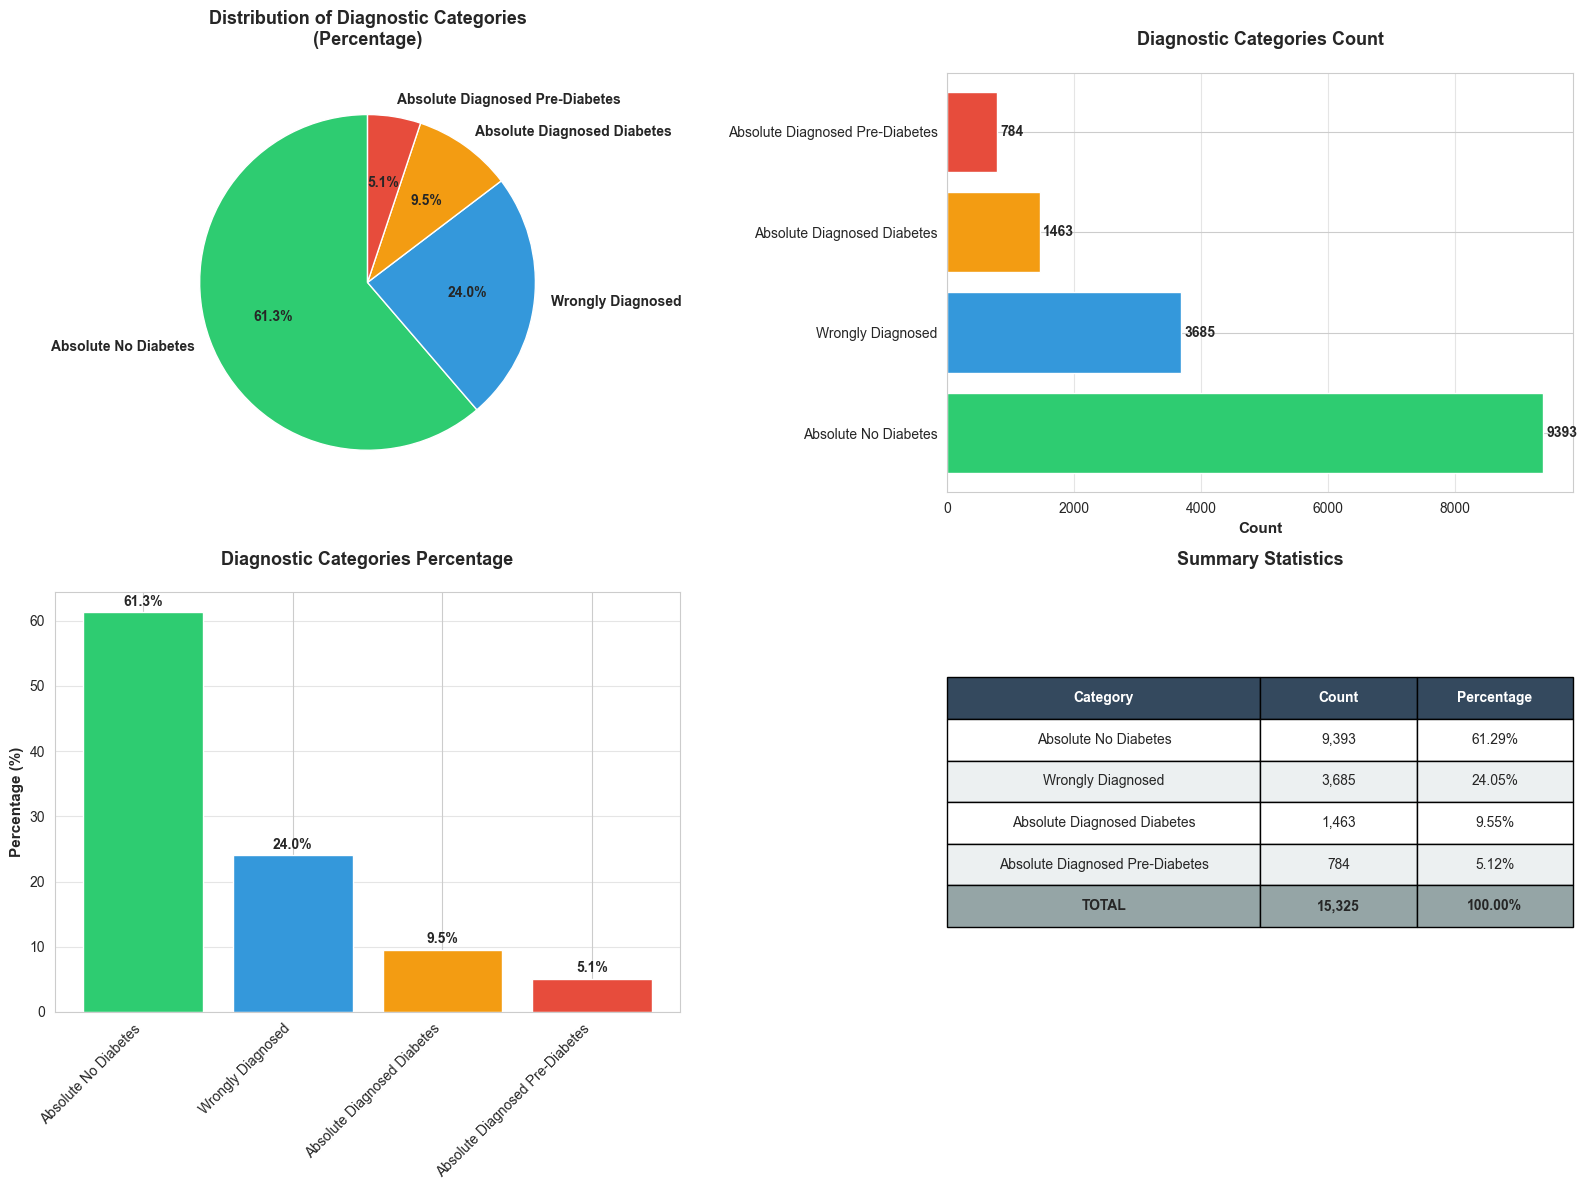


Plot saved as 'diagnostic_categories_plot.png'

DIAGNOSTIC CATEGORIES SUMMARY
  Absolute No Diabetes....................  9,393 ( 61.29%)
  Wrongly Diagnosed.......................  3,685 ( 24.05%)
  Absolute Diagnosed Diabetes.............  1,463 (  9.55%)
  Absolute Diagnosed Pre-Diabetes.........    784 (  5.12%)
  TOTAL (excl. Unclassified).............. 15,325 (100.00%)


In [9]:
# Visualize the distribution with pie chart, bar chart, and summary statistics
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Remove 'Unclassified' from plots and summary (keep original DF intact)
df_plot = df[df['diagnostic_category'] != 'Unclassified'].copy()

# Get category counts
category_counts = df_plot['diagnostic_category'].value_counts()
category_proportions = df_plot['diagnostic_category'].value_counts(normalize=True) * 100

# Create a 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Color palette
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c', '#e67e22', '#2c3e50']

# 1. Pie chart (top-left)
ax1 = axes[0, 0]
wedges, texts, autotexts = ax1.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
ax1.set_title('Distribution of Diagnostic Categories\n(Percentage)', fontsize=13, fontweight='bold', pad=20)

# 2. Horizontal bar chart with counts (top-right)
ax2 = axes[0, 1]
y_pos = range(len(category_counts))
ax2.barh(y_pos, category_counts.values, color=colors)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(category_counts.index)
ax2.set_xlabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Diagnostic Categories Count', fontsize=13, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.5)
# Add count labels on bars
for i, v in enumerate(category_counts.values):
    ax2.text(v + 50, i, str(v), va='center', fontweight='bold')

# 3. Bar chart with percentages (bottom-left)
ax3 = axes[1, 0]
x_pos = range(len(category_proportions))
bars = ax3.bar(x_pos, category_proportions.values, color=colors)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(category_proportions.index, rotation=45, ha='right')
ax3.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax3.set_title('Diagnostic Categories Percentage', fontsize=13, fontweight='bold', pad=20)
ax3.grid(axis='y', alpha=0.5)
# Add percentage labels on bars
for i, v in enumerate(category_proportions.values):
    ax3.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

# 4. Summary statistics table (bottom-right)
ax4 = axes[1, 1]
ax4.axis('off')

# Prepare summary data
summary_data = []
for category in category_counts.index:
    count = category_counts[category]
    pct = category_proportions[category]
    summary_data.append([category, f'{count:,}', f'{pct:.2f}%'])

# Add total row (excluding Unclassified)
summary_data.append(['TOTAL', f'{len(df_plot):,}', '100.00%'])

# Create table
table = ax4.table(cellText=summary_data, 
                  colLabels=['Category', 'Count', 'Percentage'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.5, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style the header
for i in range(3):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data) + 1):
    for j in range(3):
        if i == len(summary_data):  # Total row
            table[(i, j)].set_facecolor('#95a5a6')
            table[(i, j)].set_text_props(weight='bold')
        elif i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax4.set_title('Summary Statistics', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('diagnostic_categories_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'diagnostic_categories_plot.png'")
print("\n" + "="*70)
print("DIAGNOSTIC CATEGORIES SUMMARY")
print("="*70)
for category in category_counts.index:
    count = category_counts[category]
    pct = category_proportions[category]
    print(f"  {category:.<40} {count:>6,} ({pct:>6.2f}%)")
print("="*70)
print(f"  {'TOTAL (excl. Unclassified)':.<40} {len(df_plot):>6,} (100.00%)")
print("="*70)

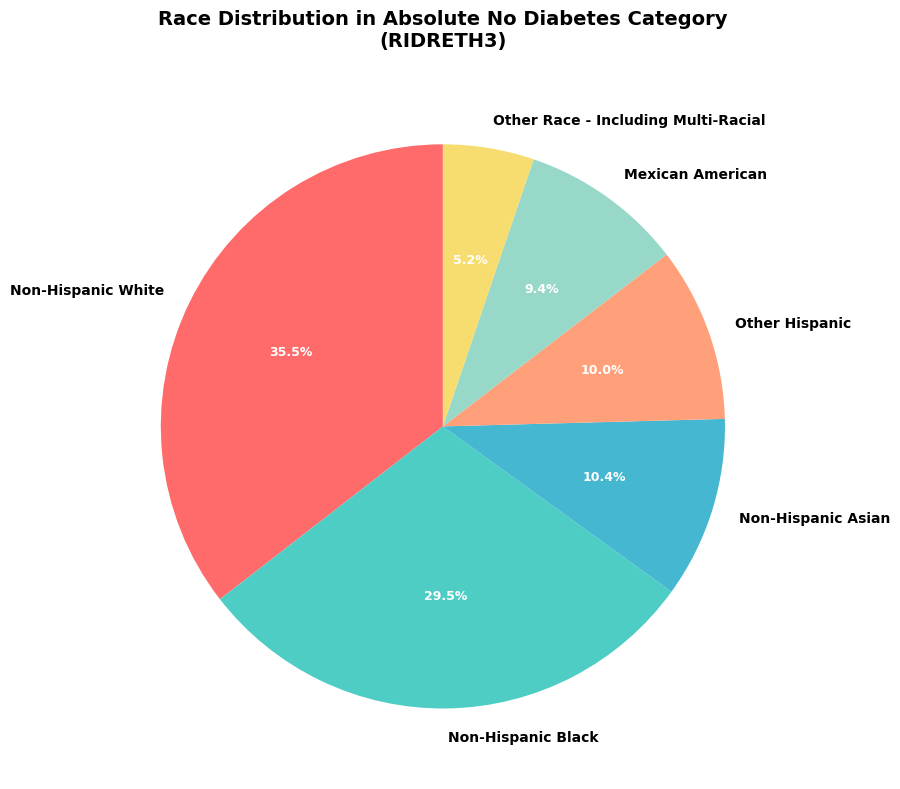


ABSOLUTE NO DIABETES - RACE DISTRIBUTION (RIDRETH3)

Total Absolute No Diabetes records: 2,820

Race Distribution:
  Non-Hispanic White...........................  1,001 ( 35.50%)
  Non-Hispanic Black...........................    833 ( 29.54%)
  Non-Hispanic Asian...........................    293 ( 10.39%)
  Other Hispanic...............................    282 ( 10.00%)
  Mexican American.............................    264 (  9.36%)
  Other Race - Including Multi-Racial..........    147 (  5.21%)


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for absolute_no_diabetes category
absolute_no_diabetes_df = df[df['diagnostic_category'] == 'Absolute No Diabetes'].copy()

# Map RIDRETH3 codes to race names
race_mapping = {
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    6: 'Non-Hispanic Asian',
    7: 'Other Race - Including Multi-Racial'
}

# Apply the mapping
absolute_no_diabetes_df['RIDRETH3_Name'] = absolute_no_diabetes_df['RIDRETH3'].map(race_mapping)

# Get race distribution for absolute_no_diabetes
race_counts = absolute_no_diabetes_df['RIDRETH3_Name'].value_counts()

# Create pie chart
fig, ax = plt.subplots(figsize=(12, 8))

# Color palette for races
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

# Create pie chart
wedges, texts, autotexts = ax.pie(race_counts, 
                                    labels=race_counts.index, 
                                    autopct='%1.1f%%',
                                    colors=colors[:len(race_counts)],
                                    startangle=90,
                                    textprops={'fontsize': 10, 'weight': 'bold'})

ax.set_title('Race Distribution in Absolute No Diabetes Category\n(RIDRETH3)', 
             fontsize=14, fontweight='bold', pad=20)

# Make percentage text more readable
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)

plt.tight_layout()
plt.savefig('absolute_no_diabetes_race_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("ABSOLUTE NO DIABETES - RACE DISTRIBUTION (RIDRETH3)")
print("="*70)
print(f"\nTotal Absolute No Diabetes records: {len(absolute_no_diabetes_df):,}")
print(f"\nRace Distribution:")
for race, count in race_counts.items():
    pct = (count / len(absolute_no_diabetes_df)) * 100
    print(f"  {race:.<45} {count:>6,} ({pct:>6.2f}%)")
print("="*70)

In [13]:
df.shape

(27493, 189)

In [10]:
df['HIQ032B'].value_counts() #medicare

HIQ032B
2.0    5368
Name: count, dtype: int64

In [14]:

df['HIQ032D'].value_counts() #medicaid

HIQ032D
4.0    6744
Name: count, dtype: int64

In [15]:
df['HIQ011'].value_counts() # people with health insurance

HIQ011
1.0    24678
2.0     2716
9.0       58
7.0       18
Name: count, dtype: int64

HIQ011
Yes    24678
No      2815
Name: count, dtype: int64


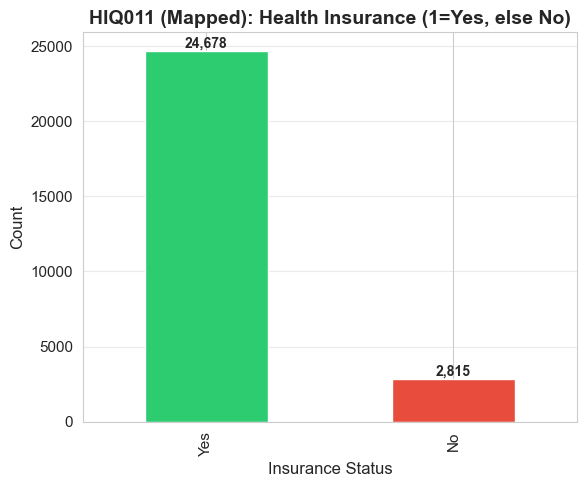

In [21]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Map HIQ011 values: 2 and all others -> "No", 1 -> "Yes"
hiq011_mapped = df['HIQ011'].apply(lambda x: 'Yes' if x == 1 else 'No')

# Value counts
counts = hiq011_mapped.value_counts()
print(counts)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('HIQ011 (Mapped): Health Insurance (1=Yes, else No)', fontsize=14, fontweight='bold')
ax.set_xlabel('Insurance Status', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.grid(axis='y', alpha=0.4)

for i, v in enumerate(counts):
    ax.text(i, v + max(counts)*0.01, f'{v:,}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('HIQ011_mapped_yes_no.png', dpi=250, bbox_inches='tight')
plt.show()


HIQ032D
No     20749
Yes     6744
Name: count, dtype: int64


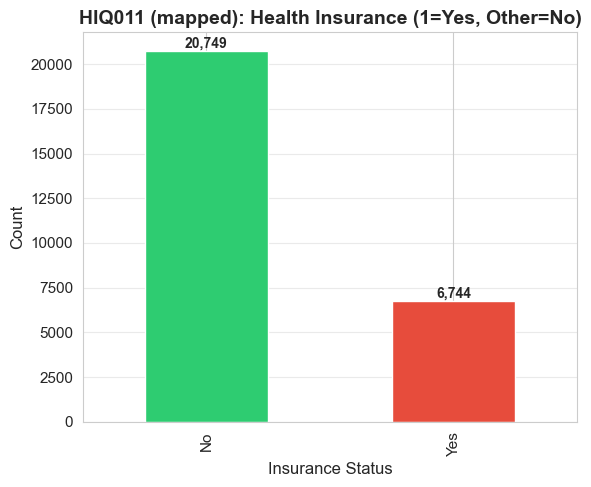

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Map 2=>Yes, everything else=>No
hiq011_mapped = df['HIQ032D'].apply(lambda x: 'Yes' if x == 4 else 'No')

# Summary counts
counts = hiq011_mapped.value_counts()
print(counts)

# Bar plot
fig, ax = plt.subplots(figsize=(6, 5))
counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('HIQ011 (mapped): Health Insurance (1=Yes, Other=No)', fontsize=14, fontweight='bold')
ax.set_xlabel('Insurance Status', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.grid(axis='y', alpha=0.4)

for i, v in enumerate(counts):
    ax.text(i, v + counts.max() * 0.01, f'{v:,}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('HIQ011_mapped_yes_no.png', dpi=250, bbox_inches='tight')
plt.show()


HIQ032B
No     22125
Yes     5368
Name: count, dtype: int64


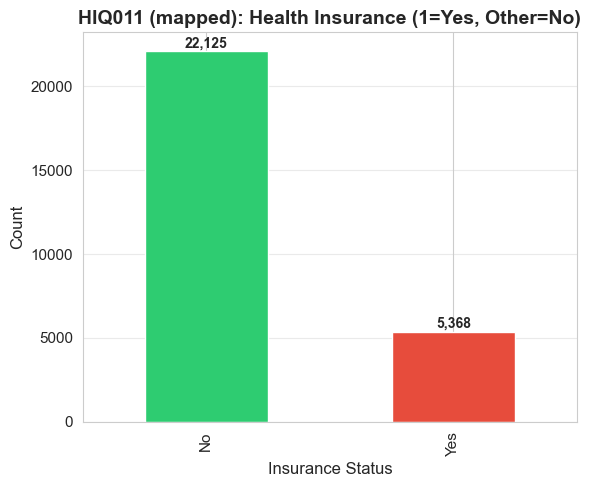

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Map 1=>Yes, everything else=>No
hiq011_mapped = df['HIQ032B'].apply(lambda x: 'Yes' if x == 2 else 'No')

# Summary counts
counts = hiq011_mapped.value_counts()
print(counts)

# Bar plot
fig, ax = plt.subplots(figsize=(6, 5))
counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('HIQ011 (mapped): Health Insurance (1=Yes, Other=No)', fontsize=14, fontweight='bold')
ax.set_xlabel('Insurance Status', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.grid(axis='y', alpha=0.4)

for i, v in enumerate(counts):
    ax.text(i, v + counts.max() * 0.01, f'{v:,}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('HIQ011_mapped_yes_no.png', dpi=250, bbox_inches='tight')
plt.show()


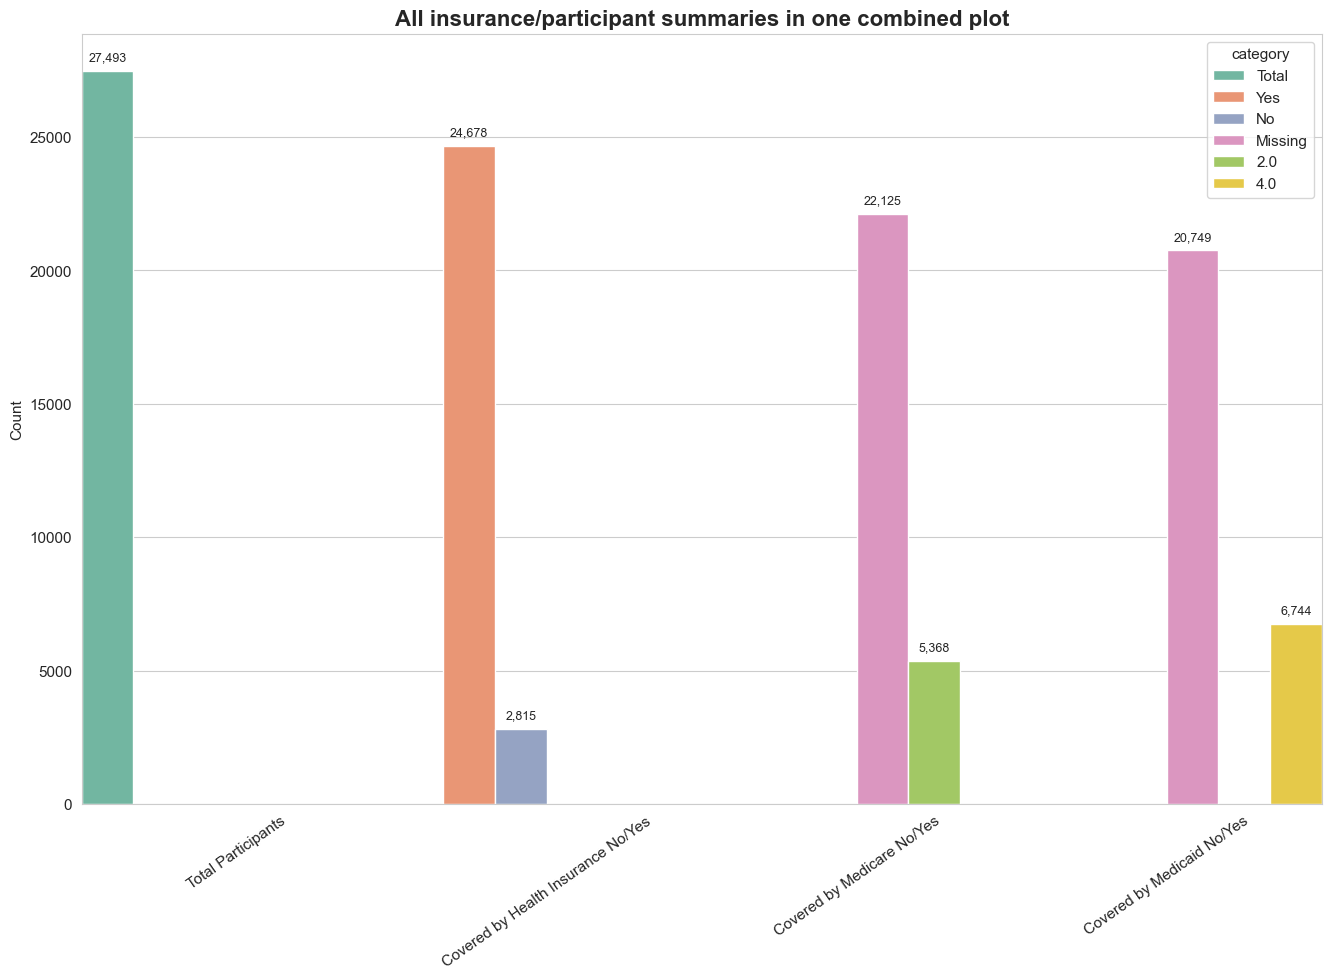

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1) Total participants (as a single bar in same plot)
total_participants = absolute_no_diabetes_df.shape[0]
total_df = pd.DataFrame({
    'variable': ['Total Participants'],
    'category': ['Total'],
    'count': [total_participants]
})

# 2) HIQ011 mapped (1=>Yes, else No)
hiq011_mapped = absolute_no_diabetes_df['HIQ011'].apply(lambda x: 'Yes' if x == 1 else 'No')
hi_df = hiq011_mapped.value_counts().reset_index()
hi_df.columns = ['category', 'count']
hi_df['variable'] = 'Covered by Health Insurance No/Yes'

# 3) HIQ032B Medicare categories
mcare_df = absolute_no_diabetes_df['HIQ032B'].fillna('Missing').astype(str).value_counts().reset_index()
mcare_df.columns = ['category', 'count']
mcare_df['variable'] = 'Covered by Medicare No/Yes'

# 4) HIQ032D Medicaid categories
mcaid_df = absolute_no_diabetes_df['HIQ032D'].fillna('Missing').astype(str).value_counts().reset_index()
mcaid_df.columns = ['category', 'count']
mcaid_df['variable'] = 'Covered by Medicaid No/Yes'

# Combine
combined = pd.concat([total_df, hi_df, mcare_df, mcaid_df], ignore_index=True)

# One plot
plt.figure(figsize=(16, 10))
ax = sns.barplot(
    data=combined,
    x='variable',
    y='count',
    hue='category',
    palette='Set2',
    width=1.0
)
ax.set_title('All insurance/participant summaries in one combined plot', fontsize=16, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=35)

# data labels
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width()/2, h + total_participants*0.01,
                f'{int(h):,}', ha='center', va='bottom', fontsize=9)

# plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
plt.savefig('all_three_in_one_visualization.png', dpi=250)
plt.show()

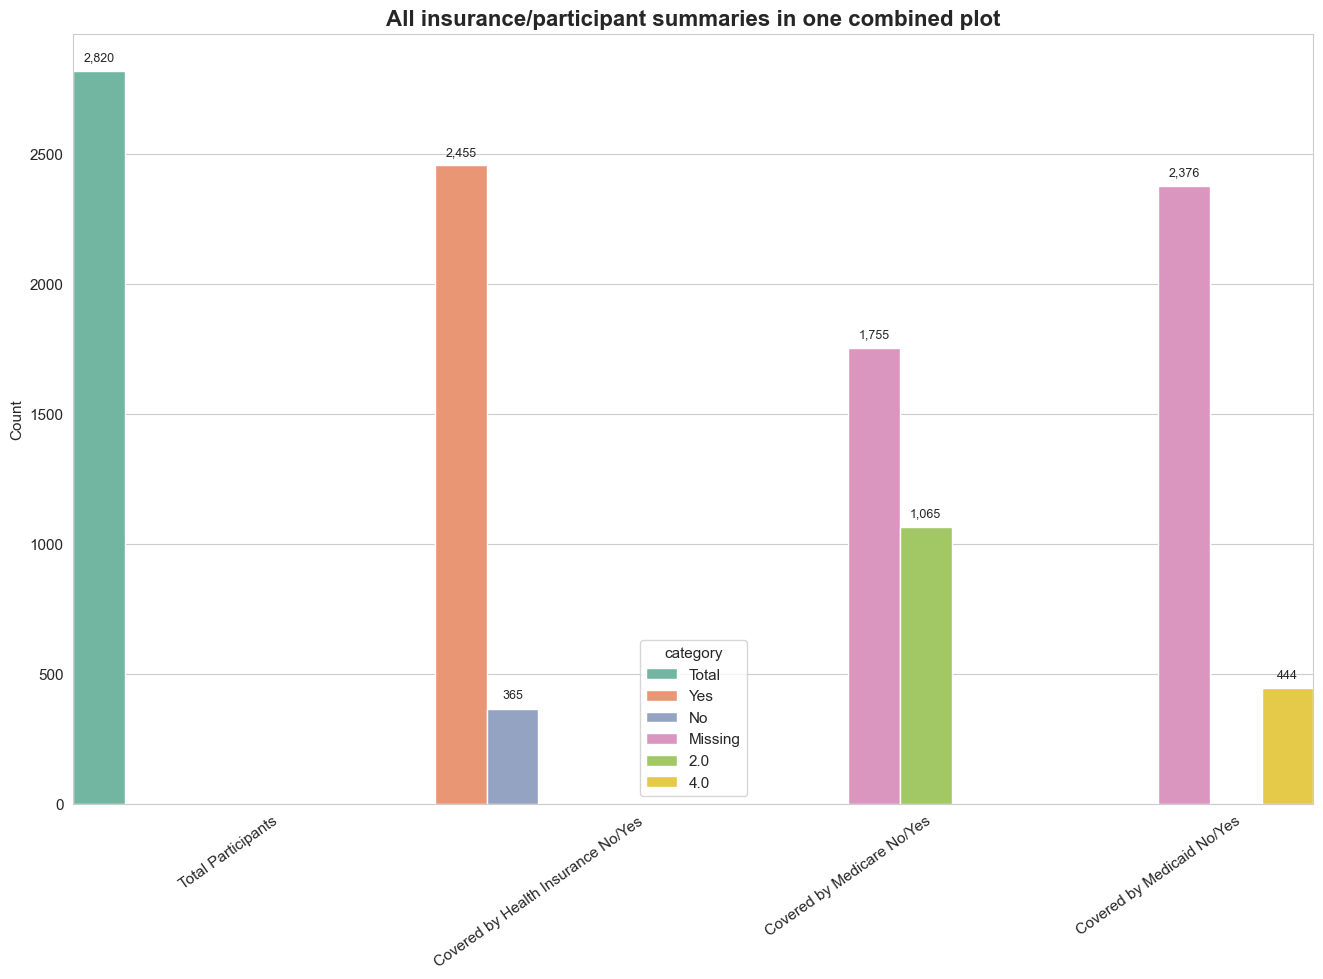

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1) Total participants (as a single bar in same plot)
total_participants = absolute_no_diabetes_df.shape[0]
total_df = pd.DataFrame({
    'variable': ['Total Participants'],
    'category': ['Total'],
    'count': [total_participants]
})

# 2) HIQ011 mapped (1=>Yes, else No)
hiq011_mapped = absolute_no_diabetes_df['HIQ011'].apply(lambda x: 'Yes' if x == 1 else 'No')
hi_df = hiq011_mapped.value_counts().reset_index()
hi_df.columns = ['category', 'count']
hi_df['variable'] = 'Covered by Health Insurance No/Yes'

# 3) HIQ032B Medicare categories
mcare_df = absolute_no_diabetes_df['HIQ032B'].fillna('Missing').astype(str).value_counts().reset_index()
mcare_df.columns = ['category', 'count']
mcare_df['variable'] = 'Covered by Medicare No/Yes'

# 4) HIQ032D Medicaid categories
mcaid_df = absolute_no_diabetes_df['HIQ032D'].fillna('Missing').astype(str).value_counts().reset_index()
mcaid_df.columns = ['category', 'count']
mcaid_df['variable'] = 'Covered by Medicaid No/Yes'

# Combine
combined = pd.concat([total_df, hi_df, mcare_df, mcaid_df], ignore_index=True)

# One plot
plt.figure(figsize=(16, 10))
ax = sns.barplot(
    data=combined,
    x='variable',
    y='count',
    hue='category',
    palette='Set2',
    width=1.0
)
ax.set_title('All insurance/participant summaries in one combined plot', fontsize=16, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=35)

# data labels
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width()/2, h + total_participants*0.01,
                f'{int(h):,}', ha='center', va='bottom', fontsize=9)

# plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
plt.savefig('all_three_in_one_visualization.png', dpi=250)
plt.show()